In [1]:
import pandas as pd


df = pd.read_csv('/home/noda/Projects/raman-spectroscopy/data/combined_raman_data.csv')


In [5]:
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# X, y = df[['Brain','Wave_1','Intensity_1','Prominence_1','Wave_2','Intensity_2','Prominence_2','Wave_3','Intensity_3','Prominence_3','Wave_4','Intensity_4','Prominence_4','Wave_5','Intensity_5','Prominence_5','Wave_6','Intensity_6','Prominence_6']], df['Label']
X = df[['Brain', 'Prominence_1', 'Prominence_2', 'Prominence_3', 'Prominence_4', 'Prominence_5', 'Prominence_6']]
y = df['Label']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

groups = df['Group']

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = CatBoostClassifier(
    iterations=2000,
    task_type="GPU",
    devices='0',
    loss_function='MultiClass',
    early_stopping_rounds=100,
    verbose=100,
    depth=7,
    random_seed=42,
    learning_rate=0.03,
    subsample=0.8,
    l2_leaf_reg=5,
    bootstrap_type='Bernoulli',
    one_hot_max_size=10,
)

model.fit(X_train, y_train, cat_features=['Brain'])

y_pred = model.predict(X_test)

score = f1_score(y_test, y_pred, average='macro')
print(score)

0:	learn: 1.0927881	total: 556ms	remaining: 18m 30s
100:	learn: 0.6261030	total: 968ms	remaining: 18.2s
200:	learn: 0.4082663	total: 1.38s	remaining: 12.4s
300:	learn: 0.2928154	total: 1.8s	remaining: 10.2s
400:	learn: 0.2239805	total: 2.21s	remaining: 8.8s
500:	learn: 0.1787503	total: 2.63s	remaining: 7.88s
600:	learn: 0.1483479	total: 3.07s	remaining: 7.14s
700:	learn: 0.1257304	total: 3.49s	remaining: 6.46s
800:	learn: 0.1087702	total: 3.91s	remaining: 5.86s
900:	learn: 0.0957221	total: 4.33s	remaining: 5.29s
1000:	learn: 0.0855387	total: 4.76s	remaining: 4.75s
1100:	learn: 0.0769445	total: 5.17s	remaining: 4.22s
1200:	learn: 0.0695127	total: 5.59s	remaining: 3.72s
1300:	learn: 0.0636992	total: 6.02s	remaining: 3.23s
1400:	learn: 0.0587766	total: 6.46s	remaining: 2.76s
1500:	learn: 0.0546665	total: 6.86s	remaining: 2.28s
1600:	learn: 0.0508693	total: 7.26s	remaining: 1.81s
1700:	learn: 0.0475111	total: 7.65s	remaining: 1.34s
1800:	learn: 0.0446737	total: 8.05s	remaining: 890ms
1900:

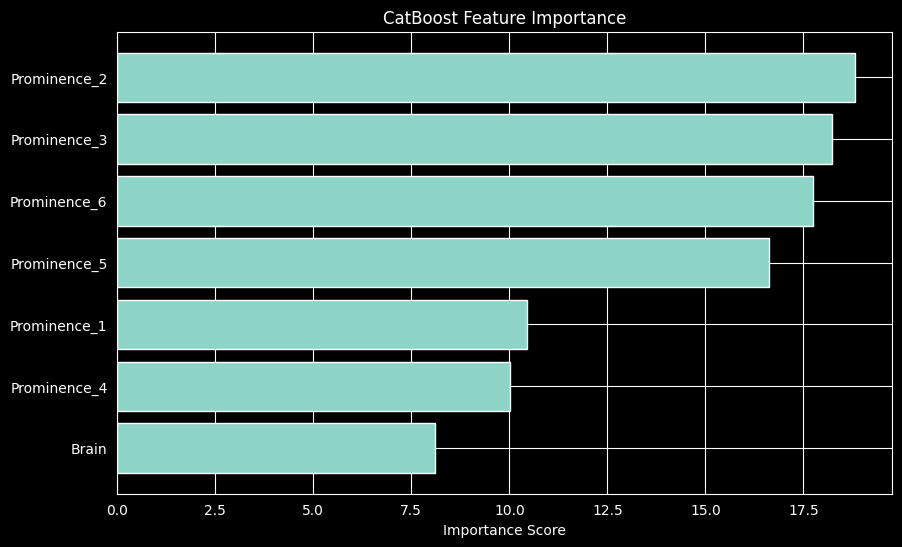

Brain: 8.0970
Prominence_1: 10.4450
Prominence_2: 18.8243
Prominence_3: 18.2256
Prominence_4: 10.0271
Prominence_5: 16.6309
Prominence_6: 17.7501


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Получаем важность признаков
feature_importance = model.get_feature_importance(type='FeatureImportance')
feature_names = X_train.columns

# Сортируем для визуализации
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.show()

# Выведем значения текстом для точности
for name, score in zip(feature_names, feature_importance):
    print(f"{name}: {score:.4f}")

In [4]:
import joblib

joblib.dump(model, '../models/model-catboost(p).joblib')


['../models/model-catboost(p).joblib']